### Tasks

* 1. Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
temp_data = 25 + 15 * np.sin(2 * np.pi * np.arange(365) / 365 - np.pi/2) + np.random.normal(0, 2, 365)
df_delhi = pd.DataFrame({'Date': dates, 'Temperature': temp_data})
df_delhi.set_index('Date', inplace=True)

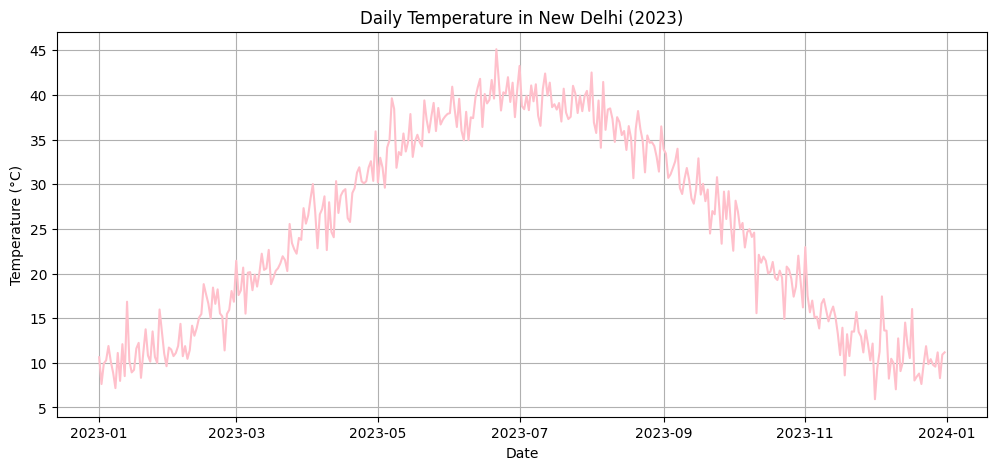

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(df_delhi.index, df_delhi['Temperature'], color='pink')
plt.title('Daily Temperature in New Delhi (2023)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

* 2. Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [42]:
decomposition = seasonal_decompose(df_delhi['Temperature'], model='additive', period=7)     # period= 7 means day=7

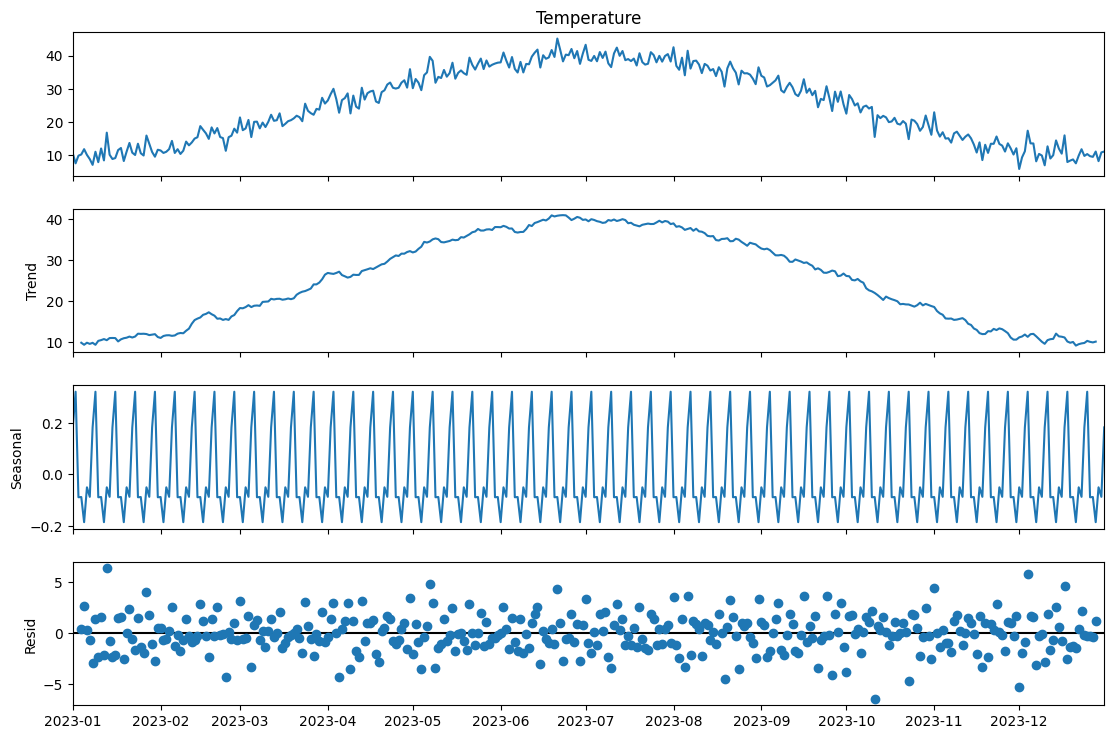

In [43]:
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

* 3. Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.<br><br><em><strong>Hint:</strong> If the p-value is less than 0.05, the series is likely stationary.</em>

In [44]:
from statsmodels.tsa.stattools import adfuller

In [45]:
adf_result = adfuller(df_delhi['Temperature'])
p_value = adf_result[1]

In [46]:
print(adf_result)

(np.float64(-0.9862398900373323), np.float64(0.758249842757613), 17, 347, {'1%': np.float64(-3.449336554273722), '5%': np.float64(-2.8699055166063085), '10%': np.float64(-2.571226758215748)}, np.float64(1560.993352349532))


In [47]:
print(f"ADF Test Statistic: {adf_result[0]:.4f}")
print(f"P-Value: {p_value:.4f}")

ADF Test Statistic: -0.9862
P-Value: 0.7582


In [48]:
if p_value < 0.05:
    print("\nConclusion: The series is stationary (we reject the null hypothesis).")
else:
    print("\nConclusion: The series is NOT stationary (it has a clear trend or seasonality).")


Conclusion: The series is NOT stationary (it has a clear trend or seasonality).


* 4. Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.

In [49]:
df_delhi['Smoothed_7Day'] = df_delhi['Temperature'].rolling(window=7).mean()

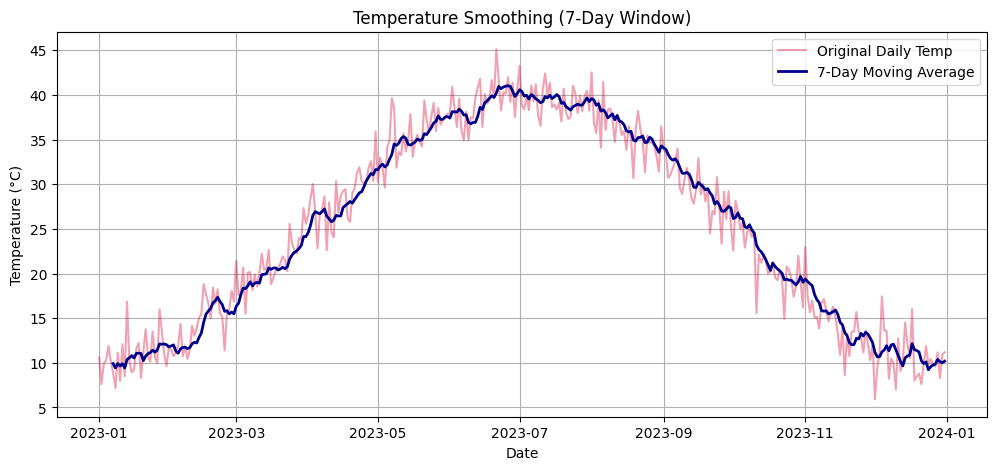

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(df_delhi.index, df_delhi['Temperature'], label='Original Daily Temp', alpha=0.4, color='crimson')
plt.plot(df_delhi.index, df_delhi['Smoothed_7Day'], label='7-Day Moving Average', color='darkblue', linewidth=2)
plt.title('Temperature Smoothing (7-Day Window)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()

* 5. Fit an ARIMA model to your temperature data using statsmodels.tsa.arima.model.ARIMA, and forecast the next 7 days. Display the predicted values and plot them along with the original series.<br><br><em><strong>Constraint:</strong> Use (p,d,q) parameters that you determine based on your ADF test and visual analysis.</em>

In [51]:
from statsmodels.tsa.arima.model import ARIMA

In [52]:
arima_model = ARIMA(df_delhi['Temperature'], order=(7, 0, 1))
arima_fit = arima_model.fit()

C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [55]:
forecast_steps = 7
forecast = arima_fit.forecast(steps=forecast_steps)

print("Predicted temperatures for the next 7 days:")
print(forecast)

Predicted temperatures for the next 7 days:
2024-01-01    10.306528
2024-01-02    10.540152
2024-01-03    10.268851
2024-01-04    10.404512
2024-01-05    10.462745
2024-01-06    10.452916
2024-01-07    10.493338
Freq: D, Name: predicted_mean, dtype: float64


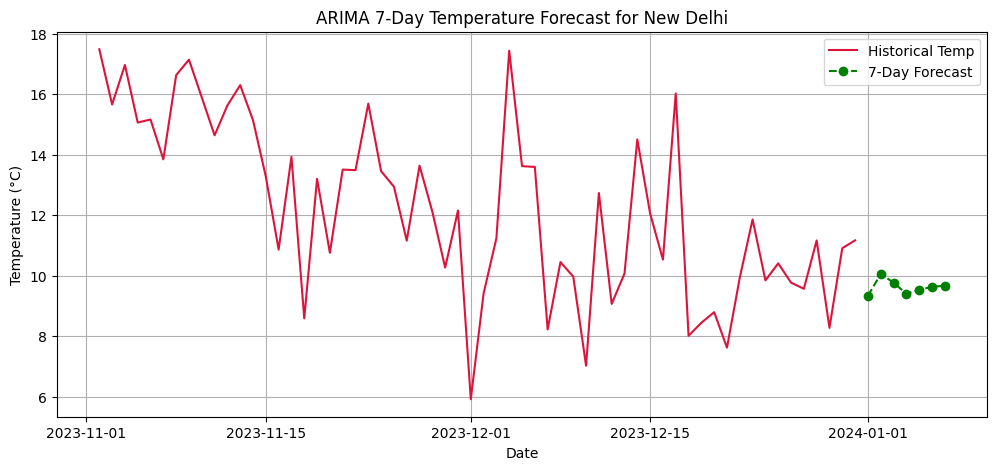

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(df_delhi.index[-60:], df_delhi['Temperature'].iloc[-60:], label='Historical Temp', color='crimson')

forecast_dates = pd.date_range(start=df_delhi.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
plt.plot(forecast_dates, forecast, label='7-Day Forecast', color='green', linestyle='dashed', marker='o')

plt.title('ARIMA 7-Day Temperature Forecast for New Delhi')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()